In [1]:
from lcr.config import PROCESSED_DATA_DIR
import pandas as pd
contextual_queries = pd.read_json(PROCESSED_DATA_DIR / "polish_final_cluster_reparsed/merged/contextual_queries.jsonl", lines=True)
chunks = pd.read_json(PROCESSED_DATA_DIR / "polish_final_cluster_reparsed/merged/chunks.jsonl", lines=True)


2026-05-09 19:16:29.858 | INFO     | lcr.config:<module>:12 - PROJ_ROOT path is: /Users/m-proj/repositories/long-context-retrieval


In [3]:
queries = contextual_queries.merge(chunks, on='chunk_id')
# index by chunk_id

chunks.set_index('chunk_id', inplace=True)

In [6]:
def id_to_idx(chunk_id):
    print(chunk_id)
    return chunks.loc[chunk_id, 'chunk_idx']

In [4]:
queries

,chunk_id,query,chunk_x,context_chunks,impl_context_chunks,utilized_context_chunk_ids,chunk_idx_x,chunk_y,implicit_context_chunks,explicit_context_chunks,chunk_idx_y
0,obligationtodefend_249,Czy wojskowe komisje lekarskie decydują o zdol...,"1a. Niezależnie od orzekania, o którym mowa w ...",Art. 29. 1. Wojskowe komisje lekarskie są właś...,,[obligationtodefend_247],249,"1a. Niezależnie od orzekania, o którym mowa w ...",[],"[obligationtodefend_243, obligationtodefend_24...",249
1,obligationtodefend_340,Czy osobom wezwanym do osobistego stawienia si...,"2) wypłaca świadczenia, o których mowa w art. ...",2. Pracownikom wezwanym do osobistego stawieni...,9. W czasie kwalifikacji wojskowej wójt lub bu...,"[obligationtodefend_599, obligationtodefend_600]",340,"2) wypłaca świadczenia, o których mowa w art. ...",[obligationtodefend_330],"[obligationtodefend_599, obligationtodefend_600]",340
2,obligationtodefend_582,Czy w jednolitej ewidencji obowiązują przepisy...,5. Do jednolitej ewidencji stosuje się odpowie...,1) dowódcom jednostek wojskowych oraz ich prze...,,"[obligationtodefend_506, obligationtodefend_50...",582,5. Do jednolitej ewidencji stosuje się odpowie...,[],"[obligationtodefend_506, obligationtodefend_50...",582
3,obligationtodefend_979,Czy w sytuacji określonej w ustępie 8 pkt 1 i ...,"1) w przypadku, o którym mowa w ust. 8 pkt 1 i...",1) w uznaniu ich zasług z tytułu udziału w wal...,8a. Mianowanie na wyższy stopień wojskowy może...,"[obligationtodefend_969, obligationtodefend_970]",979,"1) w przypadku, o którym mowa w ust. 8 pkt 1 i...",[obligationtodefend_978],"[obligationtodefend_969, obligationtodefend_970]",979
4,obligationtodefend_1043,Czy wojskowy komendant uzupełnień może przyzna...,"4. Odroczenia, o którym mowa w ust. 3, wojskow...",3. Po ustaniu przyczyn zwolnienia z zasadnicze...,,"[obligationtodefend_375, obligationtodefend_377]",1043,"4. Odroczenia, o którym mowa w ust. 3, wojskow...",[],"[obligationtodefend_1041, obligationtodefend_3...",1043
...,...,...,...,...,...,...,...,...,...,...,...
384,financingeducation_941,Jaka jest maksymalna kwota przyznawana na mate...,c) szkół podstawowych i szkół artystycznych re...,5. Odpowiednio w 2018 r. i 2019 r. dotacja cel...,"3. Dotacja celowa, o której mowa w art. 113 us...",[financingeducation_832],941,c) szkół podstawowych i szkół artystycznych re...,"[financingeducation_937, financingeducation_938]","[financingeducation_830, financingeducation_83...",941
385,financingeducation_960,Czy przepisy regulujące dotację celową na zaku...,8. Przepisów ust. 1-7 nie stosuje się do szkół...,Art. 118. 1. Odpowiednio w latach szkolnych 20...,,"[financingeducation_953, financingeducation_95...",960,8. Przepisów ust. 1-7 nie stosuje się do szkół...,[],"[financingeducation_953, financingeducation_95...",960
386,financingeducation_964,Czy minister właściwy do spraw oświaty i wycho...,Art. 119. 1. - zapewnia minister właściwy do s...,3. Publiczna szkoła podstawowa i szkoła artyst...,,[financingeducation_577],964,Art. 119. 1. - zapewnia minister właściwy do s...,[],"[financingeducation_577, financingeducation_57...",964
387,financingeducation_995,Czy szkoły artystyczne publiczne przekazane do...,Art. 122. Do dnia 31 sierpnia 2022 r. publiczn...,Art. 111. 1. Do dnia 31 sierpnia 2022 r. publi...,,[financingeducation_812],995,Art. 122. Do dnia 31 sierpnia 2022 r. publiczn...,[],[financingeducation_812],995


In [7]:
queries['utilized_idx'] = queries['utilized_context_chunk_ids'].apply(lambda ccids: [id_to_idx(ccid) for ccid in ccids])

obligationtodefend_247
obligationtodefend_599
obligationtodefend_600
obligationtodefend_506
obligationtodefend_508
obligationtodefend_512
obligationtodefend_969
obligationtodefend_970
obligationtodefend_375
obligationtodefend_377
obligationtodefend_1037
obligationtodefend_1048
obligationtodefend_1062
obligationtodefend_469
obligationtodefend_1156
obligationtodefend_1532
obligationtodefend_1537
obligationtodefend_1583
obligationtodefend_1580
obligationtodefend_1660
obligationtodefend_1679
obligationtodefend_1682
obligationtodefend_1699
obligationtodefend_1480
obligationtodefend_1716
obligationtodefend_1752
obligationtodefend_830
obligationtodefend_831
obligationtodefend_2030
obligationtodefend_2037
obligationtodefend_798
obligationtodefend_821
obligationtodefend_2079
obligationtodefend_2080
obligationtodefend_2081
obligationtodefend_2082
obligationtodefend_2083
obligationtodefend_2090
obligationtodefend_2091
obligationtodefend_2090
obligationtodefend_2091
obligationtodefend_798
obligati

In [8]:
def get_max_diff(utilized_idxs: list[int], chunk_idx: int) -> int:
    return max(abs(utilized_idx - chunk_idx) for utilized_idx in utilized_idxs)
# max utilized idx
queries['max_utilized_diff_idx'] = queries[['utilized_idx', 'chunk_idx']].apply(lambda row: get_max_diff(row['utilized_idx'], row['chunk_idx']), axis=1)

KeyError: "['chunk_idx'] not in index"

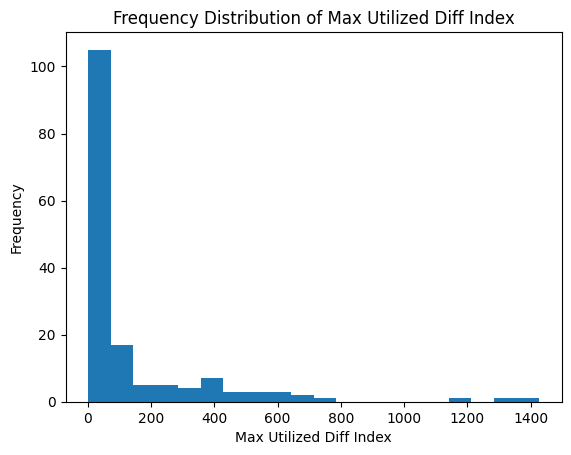

In [81]:
queries['max_utilized_diff_idx']
# do the frequency distribution of max_utilized_diff_idx
import matplotlib.pyplot as plt
plt.hist(queries['max_utilized_diff_idx'], bins=20)
plt.xlabel('Max Utilized Diff Index')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Max Utilized Diff Index')
plt.show()

In [ ]:
# redo the binning - create bins: b

## DONE

In [11]:
# count how many queries per dataset
queries['dataset'] = queries['chunk_id'].apply(lambda x: x.split('_')[0])
dataset_counts = queries['dataset'].value_counts()
print(dataset_counts)

# pick a random sample of 5 from each dataset; if fewer than 5, take all. Print chunk_id
sampled_queries = queries.groupby('dataset').apply(lambda x: x.sample(n=min(4, len(x)), random_state=42)).reset_index(drop=True)
sampled_queries[['chunk_id', 'utilized_context_chunk_ids']]
print(sampled_queries['chunk_id'])

dataset
healthcarepublicfunds    128
police                    83
socialinsurancesystem     41
financingeducation        40
statefireservice          39
obligationtodefend        32
socialassistance          26
Name: count, dtype: int64
0         financingeducation_688
1         financingeducation_653
2         financingeducation_652
3         financingeducation_839
4     healthcarepublicfunds_1580
5     healthcarepublicfunds_1208
6      healthcarepublicfunds_743
7     healthcarepublicfunds_1024
8        obligationtodefend_2223
9        obligationtodefend_1727
10       obligationtodefend_2095
11       obligationtodefend_1846
12                   police_1249
13                    police_144
14                   police_1146
15                   police_1271
16          socialassistance_634
17          socialassistance_986
18           socialassistance_68
19         socialassistance_1603
20    socialinsurancesystem_1052
21     socialinsurancesystem_622
22     socialinsurancesystem_367
23  